#Problem Statement

Use logistic Regression to classify the Titanic Dataset for binary classification. Perform the data analysis to check if the data is imbalance and apply the imbalance remedy  

In [19]:
!pip install pyspark

In [20]:
from pyspark.sql import SparkSession

spark = SparkSession \
    .builder \
    .appName("CN7030_ML_ON_BIGDATA") \
    .config("spark.some.config.option", "some-value") \
    .getOrCreate()

In [21]:
dataset = spark.read.csv('/content/titanic_synthetic_data.csv',inferSchema=True, header =True)


In [22]:
dataset.summary().show()

+-------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+-------------------+------------------+
|summary|            Pclass|               Age|             SibSp|             Parch|              Fare|               Sex|          Survived|         Embarked_Q|        Embarked_S|
+-------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+-------------------+------------------+
|  count|           1000000|           1000000|           1000000|           1000000|           1000000|           1000000|           1000000|            1000000|           1000000|
|   mean|          1.999411|         39.517847|          4.500906|          4.497493| 254.9829083944402|           0.50082|           0.49987|           0.332717|          0.333661|
| stddev|0.8168263709530482|23.092708389398037|2.8714427426552285|2.8728101169393594|141.5

In [23]:
dataset.columns


['Pclass',
 'Age',
 'SibSp',
 'Parch',
 'Fare',
 'Sex',
 'Survived',
 'Embarked_Q',
 'Embarked_S']

In [24]:
from pyspark.sql.functions import col,isnan, when, count
dataset.select([count(when(isnan(c) | col(c).isNull(), c)).alias(c) for c in dataset.columns]
   ).show()


+------+---+-----+-----+----+---+--------+----------+----------+
|Pclass|Age|SibSp|Parch|Fare|Sex|Survived|Embarked_Q|Embarked_S|
+------+---+-----+-----+----+---+--------+----------+----------+
|     0|  0|    0|    0|   0|  0|       0|         0|         0|
+------+---+-----+-----+----+---+--------+----------+----------+



In [25]:
dataset.show(5)

+------+---+-----+-----+------------------+---+--------+----------+----------+
|Pclass|Age|SibSp|Parch|              Fare|Sex|Survived|Embarked_Q|Embarked_S|
+------+---+-----+-----+------------------+---+--------+----------+----------+
|     3| 42|    6|    7|397.00178367782024|  0|       0|         0|         1|
|     1| 52|    6|    7|302.12770032784186|  0|       0|         1|         0|
|     3| 25|    3|    8| 427.1058765283985|  1|       1|         1|         0|
|     3| 32|    9|    7| 326.8049924602327|  1|       0|         0|         0|
|     1| 40|    0|    5|17.718838497771657|  0|       0|         0|         0|
+------+---+-----+-----+------------------+---+--------+----------+----------+
only showing top 5 rows


In [26]:
#us combine all the features in one single feature vector.
cols=dataset.columns
cols.remove("Survived")
# Let us import the vector assembler
from pyspark.ml.feature import VectorAssembler
assembler = VectorAssembler(inputCols=cols,outputCol="features")
# Now let us use the transform method to transform our dataset
dataset=assembler.transform(dataset)
dataset.select("features").show(truncate=False)

+-------------------------------------------------+
|features                                         |
+-------------------------------------------------+
|[3.0,42.0,6.0,7.0,397.00178367782024,0.0,0.0,1.0]|
|[1.0,52.0,6.0,7.0,302.12770032784186,0.0,1.0,0.0]|
|[3.0,25.0,3.0,8.0,427.1058765283985,1.0,1.0,0.0] |
|[3.0,32.0,9.0,7.0,326.8049924602327,1.0,0.0,0.0] |
|(8,[0,1,3,4],[1.0,40.0,5.0,17.718838497771657])  |
|[1.0,20.0,7.0,2.0,402.54904361394784,0.0,0.0,0.0]|
|[3.0,76.0,4.0,9.0,52.61038014285054,0.0,1.0,0.0] |
|[2.0,22.0,4.0,7.0,196.48213366632623,1.0,0.0,0.0]|
|[3.0,78.0,4.0,8.0,388.6259182464271,1.0,0.0,0.0] |
|[3.0,15.0,1.0,8.0,299.45900279822325,1.0,1.0,0.0]|
|[3.0,68.0,8.0,7.0,479.98134512112455,1.0,0.0,1.0]|
|[3.0,3.0,7.0,1.0,93.03405698775256,0.0,1.0,0.0]  |
|[1.0,63.0,4.0,0.0,84.64050143857706,1.0,0.0,0.0] |
|[3.0,0.0,9.0,8.0,296.7771124623517,0.0,0.0,1.0]  |
|[2.0,62.0,3.0,4.0,171.31211986091583,1.0,0.0,0.0]|
|[1.0,41.0,2.0,8.0,433.2922166813368,1.0,0.0,1.0] |
|[2.0,40.0,4

In [27]:
#Standard Sclarizer
from pyspark.ml.feature import StandardScaler
standardscaler=StandardScaler().setInputCol("features").setOutputCol("Scaled_features")
dataset=standardscaler.fit(dataset).transform(dataset)
dataset.select("features","Scaled_features").show(5)

+--------------------+--------------------+
|            features|     Scaled_features|
+--------------------+--------------------+
|[3.0,42.0,6.0,7.0...|[3.67275115824148...|
|[1.0,52.0,6.0,7.0...|[1.22425038608049...|
|[3.0,25.0,3.0,8.0...|[3.67275115824148...|
|[3.0,32.0,9.0,7.0...|[3.67275115824148...|
|(8,[0,1,3,4],[1.0...|(8,[0,1,3,4],[1.2...|
+--------------------+--------------------+
only showing top 5 rows


In [28]:
#Train, test split
train, test = dataset.randomSplit([0.8, 0.2], seed=12345)


In [37]:
 #imbalance in the dataset, observe the use of Where
dataset_size=float(train.select("Survived").count())
numPositives=train.select("Survived").where('Survived == 1').count()
per_ones=(float(numPositives)/float(dataset_size))*100
numNegatives=float(dataset_size-numPositives)
print('Dataset Size: {}'.format(dataset_size))
print('The number of ones are {}'.format(numPositives))
print('Percentage of ones are {}'.format(per_ones))

Dataset Size: 800244.0
The number of ones are 399849
Percentage of ones are 49.965885404951486


In [30]:
BalancingRatio= numNegatives/dataset_size
print('BalancingRatio = {}'.format(BalancingRatio))

BalancingRatio = 0.5003411459504851


#The dataset is balanced as there are 49.9% 1s, and 50.1% 0s.
#The class distribution is nearly perfectly split 50/50.



Since both classes contain nearly equal numbers of observations, the dataset is considered balanced.

As the class distribution is almost identical, applying imbalance handling techniques such as random oversampling, random undersampling, or SMOTE was unnecessary. Training the classification model on the original dataset helps preserve the natural data distribution while avoiding the introduction of synthetic or duplicated samples.

In [31]:
#Building a classification model using Logistic Regression (LR)
from pyspark.ml.classification import LogisticRegression

lr = LogisticRegression(labelCol="Survived", featuresCol="Scaled_features",maxIter=100)
model=lr.fit(train)
predict_train=model.transform(train)
predict_test=model.transform(test)
predict_test.select("Survived","prediction").show(10)

+--------+----------+
|Survived|prediction|
+--------+----------+
|       0|       0.0|
|       0|       0.0|
|       1|       1.0|
|       1|       0.0|
|       1|       0.0|
|       0|       0.0|
|       0|       0.0|
|       1|       0.0|
|       1|       0.0|
|       1|       0.0|
+--------+----------+
only showing top 10 rows


In [32]:
#Evaluating the model
from pyspark.ml.evaluation import BinaryClassificationEvaluator

evaluator=BinaryClassificationEvaluator(rawPredictionCol='rawPrediction',labelCol="Survived")
# We have only two choices: area under ROC and PR curves :-(
auroc = evaluator.evaluate(predict_test, {evaluator.metricName: "areaUnderROC"})

print("Area under ROC Curve: {:.4f}".format(auroc))

predict_test.select("Survived","prediction","probability").show(15)

Area under ROC Curve: 0.4973
+--------+----------+--------------------+
|Survived|prediction|         probability|
+--------+----------+--------------------+
|       0|       0.0|[0.50199403540244...|
|       0|       0.0|[0.50087056712809...|
|       1|       1.0|[0.49995200629377...|
|       1|       0.0|[0.50174044405842...|
|       1|       0.0|[0.50187025457470...|
|       0|       0.0|[0.50135988523286...|
|       0|       0.0|[0.50124551343600...|
|       1|       0.0|[0.50186344482231...|
|       1|       0.0|[0.50116173635815...|
|       1|       0.0|[0.50230827401133...|
|       1|       0.0|[0.50176779138372...|
|       1|       0.0|[0.50061158744508...|
|       0|       0.0|[0.50120171954489...|
|       0|       0.0|[0.50119396361665...|
|       1|       0.0|[0.50249214957696...|
+--------+----------+--------------------+
only showing top 15 rows


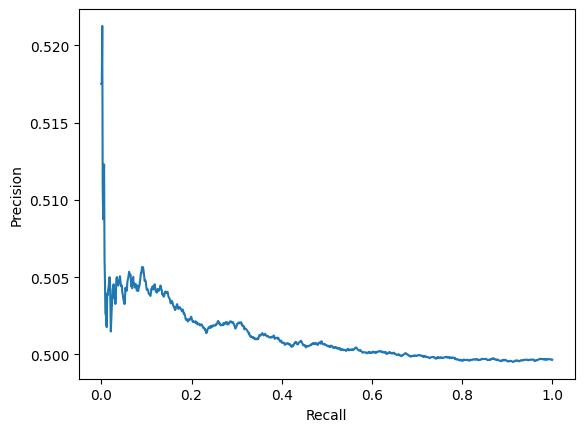

Model Accuracy 0.5011696432588061
FP rate [0.611420811356287, 0.38639343648147456]
TR rate [0.6136065635185255, 0.388579188643713]


In [33]:
print(model.summary)
import matplotlib.pyplot as plt
pr = model.summary.pr.toPandas()
plt.plot(pr['recall'],pr['precision'])
plt.ylabel('Precision')
plt.xlabel('Recall')
plt.show()
print("Model Accuracy",model.summary.accuracy)
print("FP rate",model.summary.falsePositiveRateByLabel)
print("TR rate",model.summary.truePositiveRateByLabel)

In [34]:
pr = predict_test.toPandas()
TruePositive =0
FalsePositive=0
TrueNegative=0
FalseNegative=0
Postive=1.0
Negative=0.0
pos=0
Neg=0

print("Total",len(pr["Survived"]))
for lbl in range(len(pr["Survived"])):
  if  pr["prediction"][lbl]==Postive:
    pos+=1
    if pr["prediction"][lbl]==pr["Survived"][lbl]:
      TruePositive+=1
    else:
      FalsePositive+=1
  if  pr["prediction"][lbl]==Negative:
    Neg+=1
    if pr["prediction"][lbl]==pr["Survived"][lbl]:
      TrueNegative+=1
    else:
      FalseNegative+=1
print("TruePostive",TruePositive,"FalsePostive",FalsePositive)
print("TrueNegative",TrueNegative,"FalseNegative",FalseNegative)

Total 199756
TruePostive 38408 FalsePostive 38679
TrueNegative 61056 FalseNegative 61613


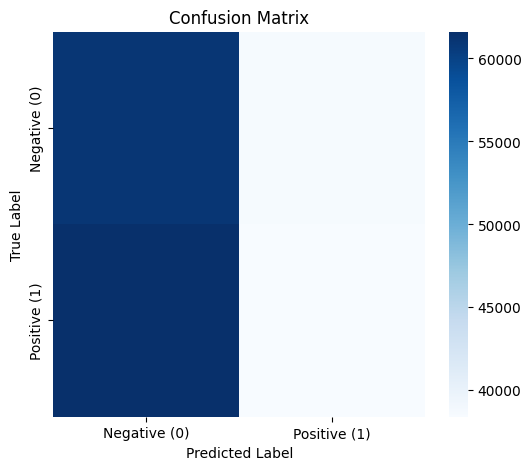

In [38]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

TN = TrueNegative
FP = FalsePositive
FN = FalseNegative
TP = TruePositive
conf_matrix = np.array([[TN, FP],
                        [FN, TP]])
labels = ["Negative (0)", "Positive (1)"]

plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix,  cmap="Blues",
            xticklabels=labels, yticklabels=labels)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

In [36]:
precision = TP / (TP + FP) if (TP + FP) > 0 else 0
recall = TP / (TP + FN) if (TP + FN) > 0 else 0
f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-score:  {f1_score:.4f}")

Precision: 0.4982
Recall:    0.3840
F1-score:  0.4337


Despite appropriate preprocessing and model training, the classifier achieved an ROC-AUC of approximately 0.50 and an accuracy of approximately 50%, indicating performance similar to random guessing. This suggests that the synthetic dataset contains weak or no meaningful relationship between the input features and the target variable. Additional feature engineering or a dataset with stronger predictive patterns would be required to improve classification performance.
